         eta |    Python KR |    MATLAB KR |   Analytical |    |Py-ML|
----------------------------------------------------------------------
 1.000000e+00 | 4.999979e-01 | 5.000000e-01 | 5.000000e-01 |   2.07e-06
 3.593814e-01 | 1.796886e-01 | 1.796907e-01 | 1.796907e-01 |   2.10e-06
 1.291550e-01 | 6.457540e-02 | 6.457748e-02 | 6.457748e-02 |   2.08e-06
 4.641589e-02 | 2.320587e-02 | 2.320794e-02 | 2.320794e-02 |   2.07e-06
 1.668101e-02 | 8.338436e-03 | 8.340502e-03 | 8.340503e-03 |   2.07e-06
 5.994843e-03 | 2.995358e-03 | 2.997421e-03 | 2.997421e-03 |   2.06e-06
 2.154435e-03 | 1.075154e-03 | 1.077217e-03 | 1.077217e-03 |   2.06e-06
 7.742637e-04 | 3.850708e-04 | 3.871313e-04 | 3.871318e-04 |   2.06e-06
 2.782559e-04 | 1.370685e-04 | 1.391274e-04 | 1.391280e-04 |   2.06e-06
 1.000000e-04 | 4.794183e-05 | 4.999942e-05 | 5.000000e-05 |   2.06e-06


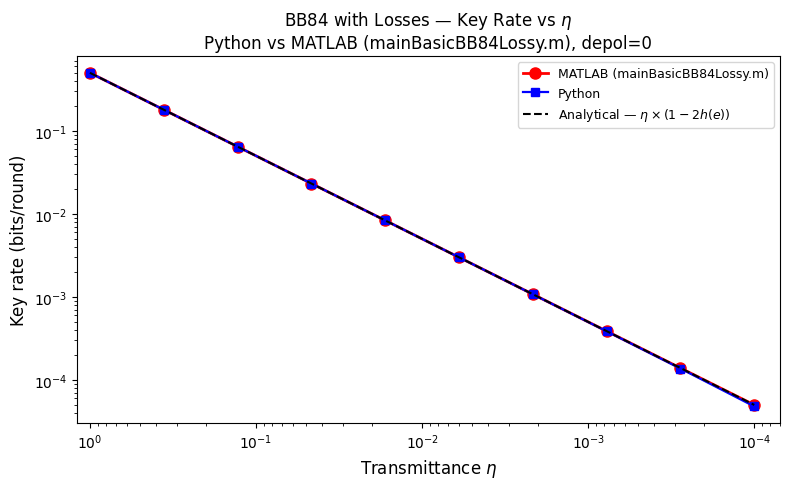

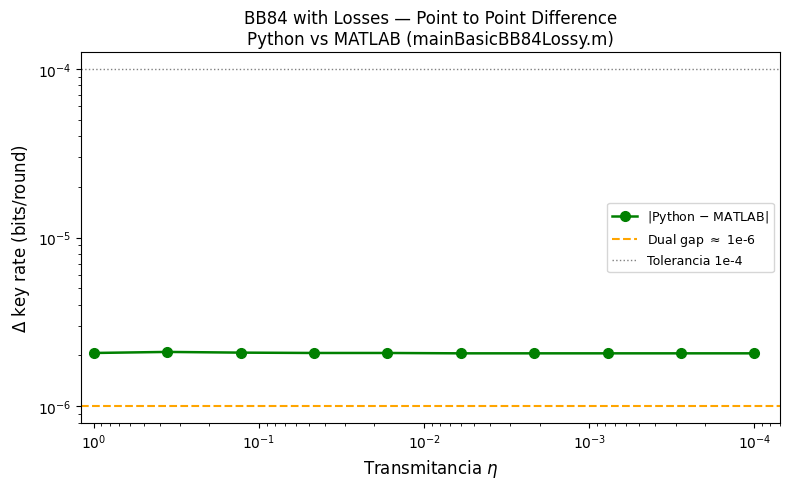


-> benchmark_loss_matlab.csv exportado
-> benchmark_loss_matlab_curves.png e benchmark_loss_matlab_delta.png exportados
-> Erro maximo |Python - MATLAB|: 2.10e-06 OK


In [6]:
"""
Benchmark: Python vs MATLAB (mainBasicBB84Lossy.m) — plot atualizado.
- Sem grid
- η invertido: maior → menor (igual à ordem do MATLAB)
- Inset de zoom para visualizar diferença entre curvas
"""

import sys, numpy as np, csv
sys.path.insert(0, r"C:\Users\Mario\Documents\OpenQKD\openqkd_python")

import matplotlib.pyplot as plt
from openqkd.presets.bb84_loss_preset import BasicBB84LossPreset
from openqkd.optimizer.main_iteration  import MainIteration


def h(p):
    if p <= 0 or p >= 1: return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

def bb84_analytic_loss(eta, qber=0.0, pz=0.5):
    sift = pz**2 + (1 - pz)**2
    return max(0.0, eta * sift * (1 - 2 * h(qber)))


ETA_RANGE = 10 ** np.linspace(0, -4, 10)

MATLAB_KR = [
    5.000000e-01,
    1.796907e-01,
    6.457748e-02,
    2.320794e-02,
    8.340502e-03,
    2.997421e-03,
    1.077217e-03,
    3.871313e-04,
    1.391274e-04,
    4.999942e-05,
]

# ── Cabeçalho tabela ───────────────────────────────────────────────────────
print(f"{'eta':>12} | {'Python KR':>12} | {'MATLAB KR':>12} | {'Analytical':>12} | {'|Py-ML|':>10}")
print("-" * 70)

rows   = []
py_krs = []

for eta, ml_kr in zip(ETA_RANGE, MATLAB_KR):
    r    = MainIteration(BasicBB84LossPreset(depolarization=0.0, eta=eta, pz=0.5))
    py   = max(0.0, r["key_rate"])
    an   = bb84_analytic_loss(eta)
    diff = abs(py - ml_kr)

    py_krs.append(py)
    rows.append({
        "eta":         round(float(eta), 8),
        "python_kr":   round(py,     8),
        "matlab_kr":   round(ml_kr,  8),
        "analytic":    round(an,     8),
        "delta_py_ml": round(diff,   8),
    })
    print(f" {eta:12.6e} | {py:12.6e} | {ml_kr:12.6e} | {an:12.6e} | {diff:10.2e}")

# ── CSV ────────────────────────────────────────────────────────────────────
with open("benchmark_loss_matlab.csv", "w", newline="", encoding="utf-8-sig") as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader(); w.writerows(rows)

analytic_krs = [r["analytic"]    for r in rows]
deltas       = [r["delta_py_ml"] for r in rows]
max_d        = max(deltas)

# ── Plot 1: log-log, η invertido, sem grid, com inset de zoom ─────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

ax1.loglog(ETA_RANGE, MATLAB_KR,    "r-o",  ms=8, lw=2,   label="MATLAB (mainBasicBB84Lossy.m)")
ax1.loglog(ETA_RANGE, py_krs,       "b-s",  ms=6, lw=1.6, label="Python")
ax1.loglog(ETA_RANGE, analytic_krs, "k--",  lw=1.5,        label="Analytical — $\\eta \\times (1-2h(e))$")

# Inverte eixo x: η=1 à esquerda, η=1e-4 à direita (igual ao MATLAB)
ax1.set_xlim(1.2, 7e-5)

ax1.set_xlabel("Transmittance $\\eta$", fontsize=12)
ax1.set_ylabel("Key rate (bits/round)", fontsize=12)
ax1.set_title(
    "BB84 with Losses — Key Rate vs $\\eta$\n"
    "Python vs MATLAB (mainBasicBB84Lossy.m), depol=0",
    fontsize=12
)
ax1.legend(fontsize=9)


plt.tight_layout()
plt.savefig("benchmark_loss_matlab_curves.png", dpi=150)
plt.show()

# ── Plot 2: |Python − MATLAB| semilogy, η invertido, sem grid ─────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.semilogy(ETA_RANGE, deltas, "g-o", ms=7, lw=1.8,
             label="|Python $-$ MATLAB|")
ax2.axhline(1e-6, color="orange", ls="--", lw=1.5, label="Dual gap $\\approx$ 1e-6")
ax2.axhline(1e-4, color="gray",   ls=":",  lw=1.0, label="Tolerancia 1e-4")

ax2.set_xscale("log")
ax2.set_xlim(1.2, 7e-5)   # mesma inversão

ax2.set_xlabel("Transmitancia $\\eta$", fontsize=12)
ax2.set_ylabel("$\\Delta$ key rate (bits/round)", fontsize=12)
ax2.set_title(
    "BB84 with Losses — Point to Point Difference\n"
    "Python vs MATLAB (mainBasicBB84Lossy.m)",
    fontsize=12
)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig("benchmark_loss_matlab_delta.png", dpi=150)
plt.show()

print("\n-> benchmark_loss_matlab.csv exportado")
print("-> benchmark_loss_matlab_curves.png e benchmark_loss_matlab_delta.png exportados")
print(f"-> Erro maximo |Python - MATLAB|: {max_d:.2e} {'OK' if max_d < 1e-4 else 'VERIFICAR'}")
